## Calibration for the stereo camera

- To do: Needs, thresholding to make image white-black instead of gray
- v1.1: Detected most checkerboards but still horrible result
- v1.0: Detected multiple checkerboards

In [ ]:
## 
import cv2
import glob
import numpy as np

def find_all_checkerboards_with_masks_enhanced(image, checkerboards_dims):
    detected_corners = []
    mask = np.ones_like(image, dtype=np.uint8)  # Initialize mask

    for checkerboard_dims in checkerboards_dims:
        while True:
            masked_image = cv2.bitwise_and(image, image, mask=mask)

            # Pre-process the image to improve contrast
            enhanced_image = cv2.equalizeHist(masked_image)

            # Find checkerboards with improved flags
            ret, corners = cv2.findChessboardCorners(enhanced_image, checkerboard_dims, 
                                                     flags=cv2.CALIB_CB_ADAPTIVE_THRESH + 
                                                           cv2.CALIB_CB_NORMALIZE_IMAGE)

            if ret:
                # Refine corners for accuracy
                # criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
                # corners = cv2.cornerSubPix(enhanced_image, corners, (11, 11), (-1, -1), criteria)
                
                detected_corners.append((corners, checkerboard_dims))

                # Mask out the detected checkerboard region (use convex hull for better masking)
                polygon_points = np.array([corner[0] for corner in corners], dtype=np.int32)
                cv2.fillConvexPoly(mask, polygon_points, 0)
            else:
                break

    return detected_corners

def processStereoImages(left_image_path, right_image_path, checkerboards_dims: list, visualize=True):
    left_img = cv2.imread(left_image_path)
    right_img = cv2.imread(right_image_path)
    gray_left = cv2.cvtColor(left_img, cv2.COLOR_BGR2GRAY)
    gray_right = cv2.cvtColor(right_img, cv2.COLOR_BGR2GRAY)

    all_corners_left = find_all_checkerboards_with_masks_enhanced(gray_left, checkerboards_dims)
    all_corners_right = find_all_checkerboards_with_masks_enhanced(gray_right, checkerboards_dims)

    if visualize:
        for corners, dims in all_corners_left:
            cv2.drawChessboardCorners(left_img, dims, corners, True)
        for corners, dims in all_corners_right:
            cv2.drawChessboardCorners(right_img, dims, corners, True)

        cv2.imshow("Left Image with All Corners", left_img)
        cv2.imshow("Right Image with All Corners", right_img)
        while True:
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break

        cv2.destroyAllWindows()

    return left_img, right_img, all_corners_left, all_corners_right

def stereoCalibration(left_img_dir, right_img_dir, corners, visualize=True):
    left_image_files = glob.glob(left_img_dir + r"\*.png")
    right_image_files = glob.glob(right_img_dir + r"\*.png")

    # left_image_files = [left_image_files[-1]]
    # right_image_files = [right_image_files[-1]]

    left_images = []
    right_images = []
    corners_left = []
    corners_right = []

    for left_image_file, right_image_file in zip(left_image_files, right_image_files):
        l, r, cl, cr = processStereoImages(left_image_file, right_image_file, corners, visualize=True)
        left_images.append(l)
        right_images.append(r)
        corners_left.append(cl)
        corners_right.append(cr)

    if visualize:
        left_image = left_images[-1]
        cs_l = corners_left[-1]
        right_image = right_images[-1]
        cs_r = corners_right[-1]
        for c_l, dims_l in cs_l:
            cv2.drawChessboardCorners(left_image, dims_l, c_l, True)
        for c_r, dims_r in cs_r:
            cv2.drawChessboardCorners(right_image, dims_r, c_r, True)

        cv2.imshow("Final Left Image with All Corners", left_image)
        cv2.imshow("Final Right Image with All Corners", right_image)

        while True:
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break

    cv2.destroyAllWindows()

# Example usage:
left_img_path = r"C:\Users\szakt\Desktop\DTU\Perception\FinalProject\34759_final_project_rect\calib\image_02\data"
right_img_path = r"C:\Users\szakt\Desktop\DTU\Perception\FinalProject\34759_final_project_rect\calib\image_03\data"

corners = [
    (7,11), (7,11), 
    (5,7), (5,7), (5,7), (5,7), (5,7), 
    (7,5), (7,5), (7,5), (7,5), (7,5), 
    (15, 5)
]
# corners = [
#     (11, 7), (11, 7),
#     (7, 5), (7, 5), (7, 5), (7, 5), (7, 5),
#     (5, 7), (5, 7), (5, 7), (5, 7), (5, 7), 
#     (5, 15)
# ]
stereoCalibration(left_img_path, right_img_path, corners, visualize=True)


## Kitti dataset LSVM
- have to have the structure:
```plaintext
kitti_dataset/
├── data_object_image_2/        # Left camera images
│   ├── training/
│   │   ├── image_2/            # Left camera images
│   │   └── image_3/            # Right camera images (optional if downloaded)
├── data_object_label_2/        # Labels
│   ├── training/
│   │   └── label_2/            # 3D object labels
├── data_object_calib/          # Calibration files
│   ├── training/
│   │   └── calib/              # Calibration data
```
-

In [ ]:
import pykitty
import cv2
import os
import numpy as np
from scipy.io import loadmat

In [ ]:

# Define paths
left_image_path = 'kitti_dataset/images/training/image_2'
right_image_path = 'kitti_dataset/images/training/image_3'

# Load an example frame (e.g., 000000.png)
frame_id = '000000'

left_image = cv2.imread(os.path.join(left_image_path, frame_id + '.png'))
right_image = cv2.imread(os.path.join(right_image_path, frame_id + '.png'))

# Display images
cv2.imshow('Left Image', left_image)
cv2.imshow('Right Image', right_image)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [ ]:
label_path = 'kitti_dataset/labels/training/label_2'

def read_labels(label_file):
    labels = []
    with open(label_file, 'r') as file:
        for line in file:
            parts = line.strip().split(' ')
            obj = {
                'type': parts[0],  # Car, Pedestrian, Cyclist
                'bbox': [float(p) for p in parts[4:8]],  # 2D bounding box in image (xmin, ymin, xmax, ymax)
                'dimensions': [float(p) for p in parts[8:11]],  # 3D dimensions (h, w, l)
                'location': [float(p) for p in parts[11:14]],  # 3D location (x, y, z)
                'rotation_y': float(parts[14]),  # Rotation around Y-axis
            }
            labels.append(obj)
    return labels

# Example usage
frame_label_file = os.path.join(label_path, frame_id + '.txt')
labels = read_labels(frame_label_file)
print(labels)


In [ ]:
calib_path = 'kitti_dataset/calib/training/calib'

def read_calib(calib_file):
    with open(calib_file, 'r') as file:
        lines = file.readlines()
        calib = {}
        for line in lines:
            key, value = line.split(':', 1)
            calib[key] = np.array([float(x) for x in value.strip().split()])
        return calib

# Example usage
frame_calib_file = os.path.join(calib_path, frame_id + '.txt')
calib = read_calib(frame_calib_file)
print(calib['P2'])  # Projection matrix for left camera


## Inference

In [ ]:
from ultralytics import YOLO

# Load the model
model = YOLO(r"C:\Users\szakt\Desktop\DTU\Perception\FinalProject\yolo11x-seg.pt")

# Input image
img_path = r'..\34759_final_project_rect\seq_03\image_02\data\0000000028.png'

# Output file path
mask_path = r"C:\Users\szakt\Desktop\DTU\Perception\FinalProject\temp.txt"

# Perform prediction
results = model.predict(source=img_path, classes=[0, 1, 2], conf=0.70)

# Clear the file content (overwrite it)
with open(mask_path, 'w') as file:
    pass  # This ensures the file is emptied before writing new content

# Save the results to the file
results[0].save_txt(mask_path)  # Save the results of the first prediction
results[0].show()  # display to screen


image 1/1 c:\Users\szakt\Desktop\DTU\Perception\FinalProject\Perception-for-Autonomous-systems-DTU-2024\..\34759_final_project_rect\seq_03\image_02\data\0000000028.png: 224x640 4 persons, 2 cars, 648.8ms
Speed: 1.5ms preprocess, 648.8ms inference, 3.5ms postprocess per image at shape (1, 3, 224, 640)


In [2]:
# result = results[0]
# boxes = result.boxes  # Boxes object for bounding box outputs
# masks = result.masks  # Masks object for segmentation masks outputs
# keypoints = result.keypoints  # Keypoints object for pose outputs
# probs = result.probs  # Probs object for classification outputs
# obb = result.obb  # Oriented boxes object for OBB outputs
# result.show()  # display to screen
# mask_path = r"C:\Users\szakt\Desktop\DTU\Perception\FinalProject\temp.txt"
# result.save_txt(mask_path)

In [31]:
import numpy as np
import cv2
import json

def get_polygon_points(image, mask_file, output_json):
    """
    Given an image and a mask file with polygon coordinates,
    extracts all pixel coordinates inside the polygon(s) and saves them into a JSON file,
    including class labels and polygon coordinates for each polygon.

    Parameters:
    - image: NumPy array representing the image (used for resolution).
    - mask_file: Path to the mask text file.
    - output_json: Path to the output JSON file.

    Returns:
    - objects_with_points: A list of dictionaries containing class labels, polygon coordinates, and points inside the polygon.
    """
    img_height, img_width = image.shape[:2]
    
    # Step 1: Parse the mask file
    objects = []
    with open(mask_file, 'r') as file:
        for line in file:
            tokens = line.strip().split()
            if len(tokens) < 3:
                continue
            class_label = int(tokens[0])
            coords = list(map(float, tokens[1:]))
            if len(coords) % 2 != 0:
                continue
            polygon = [(coords[i], coords[i + 1]) for i in range(0, len(coords), 2)]
            objects.append({
                'class_label': class_label,
                'polygon': polygon
            })
    
    # Step 2: Convert normalized coordinates to pixel coordinates
    for obj in objects:
        polygon = obj['polygon']
        pixel_polygon = [(int(round(x * img_width)), int(round(y * img_height))) for x, y in polygon]
        obj['pixel_polygon'] = pixel_polygon
    
    # Initialize the list to store objects with their points
    objects_with_points = []

    # For each object, create a mask and extract points
    for obj in objects:
        class_label = obj['class_label']
        pixel_polygon = np.array([obj['pixel_polygon']], dtype=np.int32)
        # Create a mask for the current polygon
        mask = np.zeros((img_height, img_width), dtype=np.uint8)
        cv2.fillPoly(mask, pixel_polygon, color=1)
        # Extract points inside the polygon
        y_coords, x_coords = np.where(mask == 1)
        points_inside = list(zip(map(int, x_coords), map(int, y_coords)))
        # Store the data
        objects_with_points.append({
            'class_label': class_label,
            # 'polygon': obj['pixel_polygon'],
            'points': points_inside
        })  
    
    # Save to JSON file
    with open(output_json, 'w') as f:
        json.dump(objects_with_points, f)
    
    return objects_with_points


In [32]:
mask_path = r"C:\Users\szakt\Desktop\DTU\Perception\FinalProject\temp.txt"
output_json = r"C:\Users\szakt\Desktop\DTU\Perception\FinalProject\points.json"

import numpy as np
import cv2

image = cv2.imread(img_path)

points_with_labels = get_polygon_points(image, mask_path, output_json)

print(f"Total points extracted: {len(points_with_labels)}")


Total points extracted: 6


## Image, video saving

In [ ]:
# import cv2
# import os
# from glob import glob
# from tqdm import tqdm

# def create_video_from_images(image_folder, output_video_path, fps=30):
#     """
#     Creates a video from a sequence of images.

#     Args:
#         image_folder (str): Path to the folder containing images.
#         output_video_path (str): Path to save the output video file.
#         fps (int, optional): Frames per second for the output video. Defaults to 30.
#     """
#     # Get list of image files in the folder, sorted by filename
#     image_files = sorted(glob(os.path.join(image_folder, '*')), key=os.path.getmtime)
#     image_files = [f for f in image_files if os.path.isfile(f) and f.lower().endswith(('.png', '.jpg', '.jpeg'))]

#     if not image_files:
#         print("No images found in the specified folder.")
#         return

#     # Read the first image to get dimensions
#     first_frame = cv2.imread(image_files[0])
#     if first_frame is None:
#         print(f"Failed to read image {image_files[0]}")
#         return
#     height, width, layers = first_frame.shape

#     # Define the codec and create VideoWriter object
#     fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # You can use 'XVID' or 'avc1' depending on your needs
#     video = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

#     # Iterate over images and write them to the video
#     for image_file in tqdm(image_files, "Processing images:"):
#         frame = cv2.imread(image_file)
#         if frame is None:
#             print(f"Failed to read image {image_file}, skipping.")
#             continue
#         video.write(frame)

#     video.release()
#     print(f"Video saved to {output_video_path}")

# # Create a video from the processed images
# image_folder = r"C:\Users\szakt\Desktop\DTU\Perception\FinalProject\Output"  # The folder where processed images are saved
# output_video_path = os.path.join(image_folder,"output_video.mp4")
# fps = 10  # Set frames per second for the video

# create_video_from_images(image_folder, output_video_path, fps)


Processing images:: 100%|██████████| 121/121 [00:01<00:00, 61.87it/s]

Video saved to C:\Users\szakt\Desktop\DTU\Perception\FinalProject\Output\output_video.mp4


## Pointcloud clustering

## DBSCAN

In [33]:
import cv2
import numpy as np
import json
import open3d as o3d
from image_processing import parse_calibration_data, create_seg_mask_with_mapping, RectImg2PC_for_clustering

import os

import os

def get_right_image_path(left_image_path):
    """
    Generate the right image path corresponding to a given left image path.
    
    Args:
        left_image_path (str): Path to the left image.
        
    Returns:
        str: Path to the corresponding right image.
    """
    # Split the path into components
    print("Left Image Path:", left_image_path)
    path_parts = os.path.normpath(left_image_path).split(os.sep)

    # Replace 'image_02' with 'image_03'
    if 'image_02' in path_parts:
        path_parts[path_parts.index('image_02')] = 'image_03'
    else:
        raise ValueError("Left image path does not contain 'image_02'.")

    # Reconstruct the path
    right_image_path = os.path.join(*path_parts)
    right_image_path = os.path.normpath(right_image_path)  # Normalize the path for correct formatting
    print("Right Image Path:", right_image_path)
    return right_image_path



def generate_segmented_point_cloud(
    left_image_path: str,
    right_image_path: str,
    calibration_file_path: str,
    seg_json_path: str,
    max_z: float = 20.0,
    target_class_labels: list = None,
    save_point_cloud: bool = False,
    save_path: str = 'segmented_point_cloud.npy',
    visualize: bool = False
) -> tuple:
    """
    Generates a segmented point cloud from stereo images and segmentation data.
    
    Returns:
    - point_cloud (np.ndarray): Array of shape (N, 3) or (N, 6) if colors are included.
    - mask (np.ndarray): Binary mask used for segmentation.
    """
    # Step 1: Load and convert images to grayscale
    rect_img1 = cv2.imread(left_image_path, cv2.IMREAD_GRAYSCALE)
    rect_img2 = cv2.imread(right_image_path, cv2.IMREAD_GRAYSCALE)
    
    if rect_img1 is None:
        raise FileNotFoundError(f"Left grayscale image not found at path: {left_image_path}")
    if rect_img2 is None:
        raise FileNotFoundError(f"Right grayscale image not found at path: {right_image_path}")
    
    # Step 3: Load and parse calibration data
    calibration = parse_calibration_data(calibration_file_path)
    if "P_rect_02" not in calibration or "P_rect_03" not in calibration:
        raise KeyError("Calibration data must contain 'P_rect_02' and 'P_rect_03'.")
    P_left = calibration["P_rect_02"]
    P_right = calibration["P_rect_03"]
    
    seg_mask, detection_map, detection_labels = create_seg_mask_with_mapping(
        file_path=seg_json_path,
        image_shape=rect_img1.shape,
        target_class_labels=target_class_labels
    )
    # cv2.imwrite("debug_mask.png", seg_mask.astype(np.uint8) * 255)
    for detection_id, (y_coords, x_coords) in detection_map.items():
        print(f"Detection {detection_id}: X max={x_coords.max()}, Y max={y_coords.max()}")


    point_cloud, labels = RectImg2PC_for_clustering(
        rect_img1=rect_img1,
        rect_img2=rect_img2,
        P_left=P_left,
        P_right=P_right,
        max_z=max_z,
        mask=seg_mask,
        detection_map=detection_map,
        detection_labels=detection_labels
    )

    
    # Step 6: Save the point cloud if required
    if save_point_cloud:
        np.save(save_path, point_cloud)
        print(f"Point cloud saved to {save_path}")
    
    # Step 7: Visualize the point cloud if required
    if visualize:
        # if point_cloud.points.shape[1] < 6:
        #     raise ValueError("Point cloud does not contain color information (requires at least 6 columns).")
        
        # Separate XYZ and RGB
        # xyz = point_cloud.points[:, :3]
        # rgb = point_cloud[:, 3:] / 255.0  # Normalize RGB to [0, 1]
        
        # # Create Open3D point cloud object
        # o3d_pcd = o3d.geometry.PointCloud()
        # o3d_pcd.points = o3d.utility.Vector3dVector(xyz)
        # o3d_pcd.colors = o3d.utility.Vector3dVector(rgb)
        
        # Visualize
        o3d.visualization.draw_geometries([point_cloud], window_name="Segmented Point Cloud")
    
    return point_cloud, seg_mask,labels


left_image_path = img_path
right_image_path = get_right_image_path(left_image_path)
calibration_file_path = '../34759_final_project_rect/calib_cam_to_cam.txt'
seg_json_path = '../points.json'

point_cloud, seg_mask, labels = generate_segmented_point_cloud(
    left_image_path=left_image_path,
    right_image_path=right_image_path,
    calibration_file_path=calibration_file_path,
    seg_json_path=seg_json_path,
    max_z=100.0,
    target_class_labels=None,
    save_point_cloud=False,
    save_path='segmented_point_cloud.npy',
    visualize=True  # Set to True if you want to visualize
)


Left Image Path: ..\34759_final_project_rect\seq_03\image_02\data\0000000028.png
Right Image Path: ..\34759_final_project_rect\seq_03\image_03\data\0000000028.png
Detection 0: X max=293, Y max=369
Detection 1: X max=1008, Y max=307
Detection 2: X max=484, Y max=202
Detection 3: X max=922, Y max=300
Detection 4: X max=392, Y max=279
Detection 5: X max=352, Y max=279


In [ ]:
from sklearn.cluster import DBSCAN
import numpy as np
from collections import Counter

def dbscan_with_labels_and_outlier_removal(point_cloud, labels, eps=0.5, min_samples=10):
    """
    Perform DBSCAN clustering on a point cloud, assign detection labels to centroids,
    and remove outliers from the resulting point cloud.

    Args:
        point_cloud (o3d.geometry.PointCloud): The input point cloud.
        labels (np.ndarray): Array of detection labels for each point.
        eps (float): Maximum distance between two samples for them to be considered as in the same neighborhood.
        min_samples (int): Minimum number of points in a cluster.

    Returns:
        centroids (np.ndarray): Coordinates of cluster centroids.
        cluster_labels (np.ndarray): Detection labels assigned to each centroid.
        clustered_point_cloud (o3d.geometry.PointCloud): The point cloud with DBSCAN cluster labels as colors (outliers removed).
    """
    # Extract spatial coordinates and colors
    points = np.asarray(point_cloud.points)
    colors = np.asarray(point_cloud.colors)
    
    # Combine coordinates and colors as features for clustering
    features = np.hstack((points, colors))
    
    # Perform DBSCAN clustering
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    cluster_ids = dbscan.fit_predict(features)

    # Filter out outliers (cluster ID -1)
    inlier_mask = cluster_ids != -1
    inlier_points = points[inlier_mask]
    inlier_colors = colors[inlier_mask]
    inlier_labels = labels[inlier_mask]  # Filter detection labels for inliers
    inlier_cluster_ids = cluster_ids[inlier_mask]

    # Update the point cloud to exclude outliers
    clustered_point_cloud = o3d.geometry.PointCloud()
    clustered_point_cloud.points = o3d.utility.Vector3dVector(inlier_points)
    clustered_point_cloud.colors = o3d.utility.Vector3dVector(inlier_colors)

    # Compute centroids of clusters
    centroids = []
    cluster_labels = []

    for cluster_id in np.unique(inlier_cluster_ids):
        # Get indices of points in the current cluster
        cluster_indices = np.where(inlier_cluster_ids == cluster_id)[0]

        # Compute centroid
        cluster_points = inlier_points[cluster_indices]
        centroid = np.mean(cluster_points, axis=0)
        centroids.append(centroid)

        # Assign the most frequent detection label to the cluster
        cluster_detection_labels = inlier_labels[cluster_indices]
        most_common_label = Counter(cluster_detection_labels).most_common(1)[0][0]
        cluster_labels.append(most_common_label)

    return np.array(centroids), np.array(cluster_labels), clustered_point_cloud

# Perform DBSCAN with outlier removal
centroids, cluster_labels, clustered_pcd = dbscan_with_labels_and_outlier_removal(
    point_cloud=point_cloud,
    labels=labels,
    eps=0.3,
    min_samples=500
)

# Visualize the inlier point cloud (without outliers)
o3d.visualization.draw_geometries([clustered_pcd], window_name="Clustered Point Cloud (No Outliers)")

# Print centroids and their assigned labels
for i, (centroid, label) in enumerate(zip(centroids, cluster_labels)):
    print(f"Cluster {i}: Centroid={centroid}, Assigned Label={label}")


Cluster 0: Centroid=[   0.047495    -0.36437      10.608], Assigned Label=0
Cluster 1: Centroid=[    -2.7969    -0.92133      6.1964], Assigned Label=0


In [56]:
from sklearn.cluster import KMeans

def k_means_with_labels_by_color(point_cloud, labels):
    """
    Perform K-Means clustering on a point cloud using the number of unique colors as the number of clusters,
    assign detection labels to centroids, and return the results.

    Args:
        point_cloud (o3d.geometry.PointCloud): The input point cloud.
        labels (np.ndarray): Array of detection labels for each point.

    Returns:
        centroids (np.ndarray): Coordinates of cluster centroids.
        cluster_labels (np.ndarray): Detection labels assigned to each centroid.
        clustered_point_cloud (o3d.geometry.PointCloud): The point cloud with K-Means cluster labels as colors.
    """
    # Extract spatial coordinates and colors
    points = np.asarray(point_cloud.points)
    colors = np.asarray(point_cloud.colors)
    
    # Determine the number of unique colors
    unique_colors = np.unique(colors, axis=0)
    n_clusters = len(unique_colors)

    print(f"Number of unique colors (clusters): {n_clusters}")

    # Combine coordinates and colors as features for clustering
    features = np.hstack((points, colors))
    
    # Perform K-Means clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_ids = kmeans.fit_predict(features)

    # Assign clustered points
    clustered_point_cloud = o3d.geometry.PointCloud()
    clustered_point_cloud.points = o3d.utility.Vector3dVector(points)
    clustered_point_cloud.colors = o3d.utility.Vector3dVector(colors)

    # Compute centroids of clusters
    centroids = kmeans.cluster_centers_[:, :3]  # Take only the 3D coordinates for centroids
    cluster_labels = []

    for cluster_id in range(n_clusters):
        # Get indices of points in the current cluster
        cluster_indices = np.where(cluster_ids == cluster_id)[0]

        # Assign the most frequent detection label to the cluster
        cluster_detection_labels = labels[cluster_indices]
        most_common_label = Counter(cluster_detection_labels).most_common(1)[0][0]
        cluster_labels.append(most_common_label)

    return np.array(centroids), np.array(cluster_labels), clustered_point_cloud

# Perform K-Means clustering with dynamic cluster count based on unique colors
centroids, cluster_labels, clustered_pcd = k_means_with_labels_by_color(
    point_cloud=point_cloud,
    labels=labels
)

# Visualize the clustered point cloud
o3d.visualization.draw_geometries([clustered_pcd], window_name="Clustered Point Cloud (K-Means by Color)")

# Print centroids and their assigned labels
for i, (centroid, label) in enumerate(zip(centroids, cluster_labels)):
    print(f"Cluster {i}: Centroid={centroid}, Assigned Label={label}")


Number of unique colors (clusters): 10
Cluster 0: Centroid=[    0.14575    -0.99112      10.912], Assigned Label=1
Cluster 1: Centroid=[    -2.7778    -0.51893      6.2353], Assigned Label=0
Cluster 2: Centroid=[    -6.7346    -0.56461      12.108], Assigned Label=2
Cluster 3: Centroid=[     10.879    -0.68125      19.547], Assigned Label=0
Cluster 4: Centroid=[   -0.29921   -0.093678      4.3997], Assigned Label=0
Cluster 5: Centroid=[    -12.298    -0.87103      19.724], Assigned Label=2
Cluster 6: Centroid=[      4.013     0.21505      7.6196], Assigned Label=0
Cluster 7: Centroid=[   0.051784    -0.43021       10.63], Assigned Label=0
Cluster 8: Centroid=[    -4.7808    -0.69634      8.4029], Assigned Label=0
Cluster 9: Centroid=[    -2.8139     -1.1674      6.1824], Assigned Label=0


In [62]:
def hybrid_clustering_with_outlier_handling(point_cloud, labels, eps=0.5, min_samples=10):
    """
    Hybrid DBSCAN + K-Means approach to handle outliers and cluster a point cloud.

    Args:
        point_cloud (o3d.geometry.PointCloud): The input point cloud.
        labels (np.ndarray): Array of detection labels for each point.
        n_clusters (int): The number of clusters (K) to form.
        eps (float): Maximum distance between two samples for DBSCAN.
        min_samples (int): Minimum number of points in a DBSCAN cluster.

    Returns:
        centroids (np.ndarray): Coordinates of cluster centroids.
        cluster_labels (np.ndarray): Detection labels assigned to each centroid.
        clustered_point_cloud (o3d.geometry.PointCloud): The point cloud with cluster labels.
    """
    from sklearn.cluster import DBSCAN, KMeans
    import numpy as np
    from collections import Counter

    # Extract points and colors
    points = np.asarray(point_cloud.points)
    colors = np.asarray(point_cloud.colors)
    
    # Determine the number of unique colors
    unique_colors = np.unique(colors, axis=0)
    n_clusters = len(unique_colors)

    features = np.hstack((points, colors))

    # Step 1: DBSCAN for outlier removal
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    cluster_ids = dbscan.fit_predict(features)

    # Filter inliers (cluster ID != -1)
    inlier_mask = cluster_ids != -1
    inlier_points = points[inlier_mask]
    inlier_labels = labels[inlier_mask]

    # Step 2: K-Means on inliers
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans_labels = kmeans.fit_predict(inlier_points)
    centroids = kmeans.cluster_centers_

    # Assign the most frequent detection label to each cluster
    cluster_labels = []
    for cluster_id in range(n_clusters):
        cluster_indices = np.where(kmeans_labels == cluster_id)[0]
        cluster_detection_labels = inlier_labels[cluster_indices]
        most_common_label = Counter(cluster_detection_labels).most_common(1)[0][0]
        cluster_labels.append(most_common_label)

    # Create the clustered point cloud
    clustered_point_cloud = o3d.geometry.PointCloud()
    clustered_point_cloud.points = o3d.utility.Vector3dVector(inlier_points)
    clustered_point_cloud.colors = o3d.utility.Vector3dVector(colors[inlier_mask])

    return centroids, np.array(cluster_labels), clustered_point_cloud

# Perform K-Means clustering with dynamic cluster count based on unique colors
centroids, cluster_labels, clustered_pcd = hybrid_clustering_with_outlier_handling(
    point_cloud=point_cloud,
    labels=labels,
    eps=0.5,
    min_samples=100
)

# Visualize the clustered point cloud
o3d.visualization.draw_geometries([clustered_pcd], window_name="Clustered Point Cloud (K-Means by Color)")

# Print centroids and their assigned labels
for i, (centroid, label) in enumerate(zip(centroids, cluster_labels)):
    print(f"Cluster {i}: Centroid={centroid}, Assigned Label={label}")

Cluster 0: Centroid=[    0.23502    -0.85936      11.101], Assigned Label=1
Cluster 1: Centroid=[    -2.7895     -1.0299      6.1991], Assigned Label=0
Cluster 2: Centroid=[    -6.3614    -0.43978      11.661], Assigned Label=2
Cluster 3: Centroid=[   -0.31995   -0.036037      4.2084], Assigned Label=0
Cluster 4: Centroid=[    0.03798    -0.26767      10.593], Assigned Label=0
Cluster 5: Centroid=[    -2.7584    -0.33402      6.1998], Assigned Label=0
Cluster 6: Centroid=[   0.044741    -0.77045      10.657], Assigned Label=0
Cluster 7: Centroid=[    0.18155     -1.1359      10.976], Assigned Label=1
Cluster 8: Centroid=[     -2.797    -0.72627      6.2665], Assigned Label=0
Cluster 9: Centroid=[    -2.8288     -1.2879       6.158], Assigned Label=0


In [34]:
from sklearn.cluster import DBSCAN
import numpy as np
from collections import Counter
import open3d as o3d  # Assuming Open3D is used

def dbscan_with_labels_and_outlier_removal(point_cloud, labels, eps=0.5, min_samples=10):
    """
    Perform DBSCAN clustering on a point cloud, assign detection labels to centroids,
    and remove outliers from the resulting point cloud.
    """
    points = np.asarray(point_cloud.points)
    colors = np.asarray(point_cloud.colors)
    features = np.hstack((points, colors))
    
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    cluster_ids = dbscan.fit_predict(features)

    inlier_mask = cluster_ids != -1
    inlier_points = points[inlier_mask]
    inlier_colors = colors[inlier_mask]
    inlier_labels = labels[inlier_mask]
    inlier_cluster_ids = cluster_ids[inlier_mask]

    clustered_point_cloud = o3d.geometry.PointCloud()
    clustered_point_cloud.points = o3d.utility.Vector3dVector(inlier_points)
    clustered_point_cloud.colors = o3d.utility.Vector3dVector(inlier_colors)

    centroids = []
    cluster_labels = []

    for cluster_id in np.unique(inlier_cluster_ids):
        cluster_indices = np.where(inlier_cluster_ids == cluster_id)[0]
        cluster_points = inlier_points[cluster_indices]
        centroid = np.mean(cluster_points, axis=0)
        centroids.append(centroid)

        cluster_detection_labels = inlier_labels[cluster_indices]
        most_common_label = Counter(cluster_detection_labels).most_common(1)[0][0]
        cluster_labels.append(most_common_label)

    return np.array(centroids), np.array(cluster_labels), clustered_point_cloud, len(np.unique(inlier_cluster_ids))

# Extract the number of clusters based on unique colors
colors = np.asarray(point_cloud.colors)
unique_colors = np.unique(colors, axis=0)
n_clusters = len(unique_colors)
print(f"Number of unique colors (clusters): {n_clusters}")

# Grid search for DBSCAN parameters
eps_values = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55]
min_samples_values = [50, 100, 150, 200, 350, 300, 400, 500,750, 1000]
min_samples_values = min_samples_values[::-1]
best_params = None
best_centroids = None
best_cluster_labels = None
best_clustered_pcd = None

for eps in eps_values:
    for min_samples in min_samples_values:
        print(f"Trying eps={eps}, min_samples={min_samples}...")
        try:
            centroids, cluster_labels, clustered_pcd, num_clusters = dbscan_with_labels_and_outlier_removal(
                point_cloud=point_cloud,
                labels=labels,
                eps=eps,
                min_samples=min_samples
            )
            print(num_clusters)

            # Match number of clusters with expected count
            if num_clusters == n_clusters:
                print(f"Match found: eps={eps}, min_samples={min_samples}, clusters={num_clusters}")
                best_params = (eps, min_samples)
                best_centroids = centroids
                best_cluster_labels = cluster_labels
                best_clustered_pcd = clustered_pcd
                break
        except Exception as e:
            print(f"Error with eps={eps}, min_samples={min_samples}: {e}")

    if best_params:
        break  # Exit outer loop if a match is found

# Visualize the best result
if best_clustered_pcd:
    print(f"Best parameters: eps={best_params[0]}, min_samples={best_params[1]}")
    o3d.visualization.draw_geometries([best_clustered_pcd], window_name="Best Clustered Point Cloud")
    for i, (centroid, label) in enumerate(zip(best_centroids, best_cluster_labels)):
        print(f"Cluster {i}: Centroid={centroid}, Assigned Label={label}")
else:
    print("No matching parameters found in the grid search.")


Number of unique colors (clusters): 6
Trying eps=0.3, min_samples=1000...
4
Trying eps=0.3, min_samples=750...
5
Trying eps=0.3, min_samples=500...
5
Trying eps=0.3, min_samples=400...
5
Trying eps=0.3, min_samples=300...
5
Trying eps=0.3, min_samples=350...
5
Trying eps=0.3, min_samples=200...
5
Trying eps=0.3, min_samples=150...
5
Trying eps=0.3, min_samples=100...
8
Trying eps=0.3, min_samples=50...
14
Trying eps=0.35, min_samples=1000...
5
Trying eps=0.35, min_samples=750...
5
Trying eps=0.35, min_samples=500...
5
Trying eps=0.35, min_samples=400...
5
Trying eps=0.35, min_samples=300...
5
Trying eps=0.35, min_samples=350...
5
Trying eps=0.35, min_samples=200...
5
Trying eps=0.35, min_samples=150...
5
Trying eps=0.35, min_samples=100...
10
Trying eps=0.35, min_samples=50...
15
Trying eps=0.4, min_samples=1000...
5
Trying eps=0.4, min_samples=750...
5
Trying eps=0.4, min_samples=500...
5
Trying eps=0.4, min_samples=400...
5
Trying eps=0.4, min_samples=300...
5
Trying eps=0.4, min_sam

In [35]:
import open3d as o3d
import numpy as np

def visualize_point_cloud_with_centroids(
    point_cloud, cluster_labels, centroids, centroid_labels, unique_label_colors=None
):
    """
    Visualize a point cloud with clusters and centroids using spheres for centroids.

    Args:
        point_cloud (o3d.geometry.PointCloud): The clustered point cloud.
        cluster_labels (np.ndarray): Cluster labels for each point.
        centroids (np.ndarray): Centroid positions for each cluster.
        centroid_labels (np.ndarray): Labels assigned to each centroid.
        unique_label_colors (dict or None): Predefined colors for clusters and centroids.
    """
    # Generate unique colors for each cluster if not provided
    if unique_label_colors is None:
        unique_labels = np.unique(cluster_labels)
        unique_label_colors = {
            label: np.random.rand(3) for label in unique_labels if label >= 0
        }

    # Assign colors to each point based on its cluster label
    points = np.asarray(point_cloud.points)
    colors = np.array([
        unique_label_colors[label] if label >= 0 else [0, 0, 0]  # Black for outliers
        for label in cluster_labels
    ])
    point_cloud.colors = o3d.utility.Vector3dVector(colors)

    # Create a list of geometry objects for visualization
    geometries = [point_cloud]

    # Add centroids as spheres
    for i, (centroid, label) in enumerate(zip(centroids, centroid_labels)):
        # Create a sphere for the centroid
        sphere = o3d.geometry.TriangleMesh.create_sphere(radius=0.2)
        sphere.translate(centroid)  # Move sphere to centroid position
        sphere.paint_uniform_color([0, 0, 0])  # Use cluster color
        geometries.append(sphere)

        # Print the label in the terminal for reference
        print(f"Centroid {i}: Position={centroid}, Class={label}")

    # Visualize the point cloud and centroids
    o3d.visualization.draw_geometries(
        geometries,
        window_name="Point Cloud with Centroids",
    )


# Visualize the clustered point cloud with centroids and labels
visualize_point_cloud_with_centroids(
    point_cloud=best_clustered_pcd,
    cluster_labels=labels,
    centroids=best_centroids,
    centroid_labels=best_cluster_labels
)


Centroid 0: Position=[     -3.386    -0.63619      6.9386], Class=0
Centroid 1: Position=[    -3.1017    -0.53851      7.4983], Class=0
Centroid 2: Position=[     3.6376    -0.44846      9.6665], Class=0
Centroid 3: Position=[     3.3227    -0.66967      10.182], Class=0
Centroid 4: Position=[     2.2638    -0.76962      3.8857], Class=2
Centroid 5: Position=[     5.2583     -1.3918      9.5473], Class=2


# Main Kalman filtering test and calculating covariance: 

## Normal loop

In [1]:
import os
import glob
from pointcloud_clustering import *
from tracking import *
from image_processing import *
from ultralytics import YOLO
from main import *

# model = YOLO(r"C:\Users\szakt\Desktop\DTU\Perception\FinalProject\fine_tuned_yolo.pt")
model = YOLO(r"C:\Users\szakt\Desktop\DTU\Perception\FinalProject\yolo11x-seg.pt")

rect_folder = r"C:\Users\szakt\Desktop\DTU\Perception\FinalProject\34759_final_project_rect"
seq = "seq_01"
frame_count = 8

# classes = [0,4,8]
classes = [0,1,2]

seq_list = getImageSeq(path=rect_folder, seq=seq, frame_count=frame_count)


# Parameters
cost_threshold = 50
class_mismatch_penalty = 1000
max_age = 5

# Main tracking loop
tracked_objects = []
all_tracked_objects = []
next_object_id = 0

for frame_idx, (frame_left, frame_right) in enumerate(zip(seq_list["left"],seq_list["right"])):
    print(f"\nProcessing frame {frame_idx + 1}/{len(seq_list['left'])}")
    
    calibration_file_path = seq_list["calibration"]
    current_detections = cluster_from_stereo(model, classes, frame_left, frame_right, calibration_file_path, conf= 0.7, save_results= False, visualize = False)
    print(f"Number of current detections: {len(current_detections)}")

    # Predict tracked object positions
    for obj in tracked_objects:
        obj.predict()
    
    # Assign detections to tracked objects
    previous_detections = [Detection(obj.centroid, obj.class_label) for obj in tracked_objects]
    
    matches, unmatched_prev, unmatched_curr = assign_centroids(
        previous_detections,
        current_detections,
        cost_threshold=cost_threshold,
        class_mismatch_penalty=class_mismatch_penalty
    )
    
    print(f"Matches: {matches}")
    print(f"Unmatched previous detections: {unmatched_prev}")
    print(f"Unmatched current detections: {unmatched_curr}")
    
    # Update matched tracked objects
    for prev_idx, curr_idx in matches:
        tracked_objects[prev_idx].update(current_detections[curr_idx])
    
    # Increase time_since_update for unmatched previous objects
    for idx in unmatched_prev:
        tracked_objects[idx].time_since_update += 1
    
    # Create new tracked objects for unmatched current detections
    for idx in unmatched_curr:
        obj = TrackedObject(current_detections[idx], next_object_id)
        tracked_objects.append(obj)
        next_object_id += 1
    
    # Remove lost tracked objects
    lost_objects = [obj for obj in tracked_objects if obj.time_since_update > max_age]
    tracked_objects = [obj for obj in tracked_objects if obj.time_since_update <= max_age]
    all_tracked_objects.extend(lost_objects)

# After the loop, add remaining tracked objects
all_tracked_objects.extend(tracked_objects)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.

Processing frame 1/8

image 1/1 C:\Users\szakt\Desktop\DTU\Perception\FinalProject\34759_final_project_rect\seq_01\image_02\data\000000.png: 224x640 2 persons, 666.3ms
Speed: 2.3ms preprocess, 666.3ms inference, 2.6ms postprocess per image at shape (1, 3, 224, 640)
Detection 0: X max=499, Y max=353
Detection 1: X max=553, Y max=330
Best parameters: eps=0.2, min_samples=750
Centroid 0: Position=[   -0.86599     0.57867      6.9129], Class=0
Centroid 1: Position=[    -1.4405     0.72682      6.0376], Class=0
Number of current detections: 2
Matches: []
Unmatched previous detections: []
Unmatched current detections: [0, 1]

Processing frame 2/8

image 1/1 C:\Users\szakt\Desktop\DTU\Perception\FinalProject\34759_final_project_rect\seq_01\image_02\data\000001.png: 224x640 2 persons, 718.1ms
Speed: 5.0ms preprocess, 718.1ms i

TypeError: TrackedObject.predict() missing 1 required positional argument: 'current_timestamp'

In [ ]:
visualize_tracked_objects_histories(tracked_objects)

## Covariance calc

In [1]:
import os
import glob
from pointcloud_clustering import *
from tracking import *
from image_processing import *
from ultralytics import YOLO
from main import *
from kalmanfilter import *

# model = YOLO(r"C:\Users\szakt\Desktop\DTU\Perception\FinalProject\fine_tuned_yolo.pt")
model = YOLO(r"C:\Users\szakt\Desktop\DTU\Perception\FinalProject\yolo11x-seg.pt")

rect_folder = r"C:\Users\szakt\Desktop\DTU\Perception\FinalProject\34759_final_project_rect"
seq = "seq_01"
frame_count = 8

# classes = [0,4,8]
classes = [0,1,2]

seq_list = getImageSeq(path=rect_folder, seq=seq, frame_count=frame_count)

cov_estimator = MeasurementCovarianceEstimator(window_size=20)

# Parameters
cost_threshold = 50
class_mismatch_penalty = 1000
max_age = 5

# Main tracking loop
tracked_objects = []
all_tracked_objects = []
next_object_id = 0

for frame_idx, (frame_left, frame_right) in enumerate(zip(seq_list["left"],seq_list["right"])):
    print(f"\nProcessing frame {frame_idx + 1}/{len(seq_list['left'])}")
    
    calibration_file_path = seq_list["calibration"]
    current_detections = cluster_from_stereo(model, classes, frame_left, frame_right, calibration_file_path, conf= 0.7, save_results= False, visualize = False)
    print(f"Number of current detections: {len(current_detections)}")

    for detection in current_detections:
        # Add measurement to covariance estimator
        cov_estimator.add_measurement(detection.centroid, detection.class_label)
        
    # Create tracked objects with covariance estimator
    for detection in current_detections:
        obj = TrackedObject(
            detection, 
            next_object_id, 
            cov_estimator=cov_estimator  # Pass covariance estimator
        )

    # Predict tracked object positions
    for obj in tracked_objects:
        obj.predict()
    
    # Assign detections to tracked objects
    previous_detections = [Detection(obj.centroid, obj.class_label) for obj in tracked_objects]
    
    matches, unmatched_prev, unmatched_curr = assign_centroids(
        previous_detections,
        current_detections,
        cost_threshold=cost_threshold,
        class_mismatch_penalty=class_mismatch_penalty
    )
    
    print(f"Matches: {matches}")
    print(f"Unmatched previous detections: {unmatched_prev}")
    print(f"Unmatched current detections: {unmatched_curr}")
    
    # Update matched tracked objects
    for prev_idx, curr_idx in matches:
        tracked_objects[prev_idx].update(current_detections[curr_idx])
    
    # Increase time_since_update for unmatched previous objects
    for idx in unmatched_prev:
        tracked_objects[idx].time_since_update += 1
    
    # Create new tracked objects for unmatched current detections
    for idx in unmatched_curr:
        obj = TrackedObject(current_detections[idx], next_object_id)
        tracked_objects.append(obj)
        next_object_id += 1
    
    # Remove lost tracked objects
    lost_objects = [obj for obj in tracked_objects if obj.time_since_update > max_age]
    tracked_objects = [obj for obj in tracked_objects if obj.time_since_update <= max_age]
    all_tracked_objects.extend(lost_objects)

# After the loop, add remaining tracked objects
all_tracked_objects.extend(tracked_objects)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.

Processing frame 1/8

image 1/1 C:\Users\szakt\Desktop\DTU\Perception\FinalProject\34759_final_project_rect\seq_01\image_02\data\000000.png: 224x640 2 persons, 585.4ms
Speed: 1.3ms preprocess, 585.4ms inference, 2.3ms postprocess per image at shape (1, 3, 224, 640)
Detection 0: X max=499, Y max=353
Detection 1: X max=553, Y max=330
Best parameters: eps=0.2, min_samples=750
Centroid 0: Position=[   -0.86599     0.57867      6.9129], Class=0
Centroid 1: Position=[    -1.4405     0.72682      6.0376], Class=0
Number of current detections: 2
Matches: []
Unmatched previous detections: []
Unmatched current detections: [0, 1]

Processing frame 2/8

image 1/1 C:\Users\szakt\Desktop\DTU\Perception\FinalProject\34759_final_project_rect\seq_01\image_02\data\000001.png: 224x640 2 persons, 547.1ms
Speed: 2.2ms preprocess, 547.1ms i

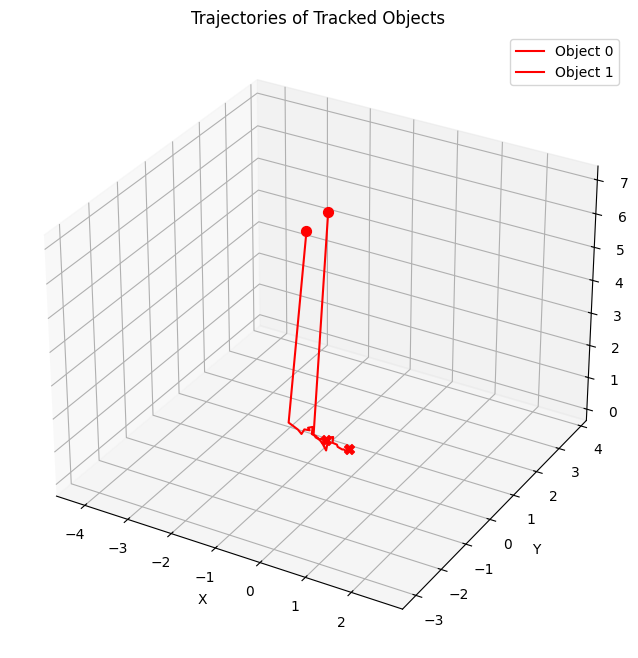

In [2]:
visualize_tracked_objects_histories(tracked_objects)

In [7]:
import open3d as o3d
from main import play_point_cloud_sequence_with_trails
import numpy as np

ply_path = r"C:\Users\szakt\Desktop\DTU\Perception\FinalProject\frame_data"

scaler = 4
view_params = {
    'front': [0.25, -0.2, -1],
    'lookat': scaler * np.array([-0.75, 0.59465, 6.0202]),
    'up': [0, -1, 0],
    'zoom': 0.8
} 

play_point_cloud_sequence_with_trails(ply_path,view_params)

In [6]:
import os
import numpy as np
from main import capture_point_cloud_sequence
# Create output directory for images
image_output_dir = r"C:\Users\szakt\Desktop\DTU\Perception\FinalProject\frames"

ply_path = r"C:\Users\szakt\Desktop\DTU\Perception\FinalProject\frame_data"
# Capture sequence
scaler = 4
view_params = {
    'front': [0.25, -0.2, -1],
    'lookat': scaler * np.array([-0.75, 0.59465, 6.0202]),
    'up': [0, -1, 0],
    'zoom': 0.8
} 
capture_point_cloud_sequence(
    folder_path=ply_path,
    output_image_dir=image_output_dir,
    view_params=view_params,
    width=1920,  # Full HD resolution
    height=1080
)

Captured frame: 0024
Capture complete!


KeyboardInterrupt: 

In [5]:
import cv2
import os
from glob import glob
from tqdm import tqdm

def create_video_from_images(image_folder, output_video_path, fps=30):
    """
    Creates a video from a sequence of images.

    Args:
        image_folder (str): Path to the folder containing images.
        output_video_path (str): Path to save the output video file.
        fps (int, optional): Frames per second for the output video. Defaults to 30.
    """
    # Get list of image files in the folder, sorted by filename
    image_files = sorted(glob(os.path.join(image_folder, '*')), key=os.path.getmtime)
    image_files = [f for f in image_files if os.path.isfile(f) and f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if not image_files:
        print("No images found in the specified folder.")
        return

    # Read the first image to get dimensions
    first_frame = cv2.imread(image_files[0])
    if first_frame is None:
        print(f"Failed to read image {image_files[0]}")
        return
    height, width, layers = first_frame.shape

    # Define the codec and create VideoWriter object
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # You can use 'XVID' or 'avc1' depending on your needs
    video = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    # Iterate over images and write them to the video
    for image_file in tqdm(image_files, "Processing images:"):
        frame = cv2.imread(image_file)
        if frame is None:
            print(f"Failed to read image {image_file}, skipping.")
            continue
        video.write(frame)

    video.release()
    print(f"Video saved to {output_video_path}")

# Create a video from the processed images
image_folder = r"C:\Users\szakt\Desktop\DTU\Perception\FinalProject\frames"  # The folder where processed images are saved
output_video_path = os.path.join(image_folder,"video_tracking.mp4")
fps = 10  # Set frames per second for the video

create_video_from_images(image_folder, output_video_path, fps)


Processing images:: 100%|██████████| 50/50 [00:02<00:00, 23.63it/s]

Video saved to C:\Users\szakt\Desktop\DTU\Perception\FinalProject\frames\video_tracking.mp4
